In [67]:
import numpy as np

In [68]:
class MeanSquaredError():
    def forward(self,y_true,y_pred):
        m = len(y_true)
        return np.sum((y_pred-y_true)**2)/m
    def backward(self,y_true,y_pred):
        m = len(y_true)
        return 2*(y_pred-y_true)/m

In [69]:
class L1Regularization:
    def __init__(self, lambda_reg=0.1):
        self.lambda_reg = lambda_reg
    def forward(self, weights):
        return self.lambda_reg * np.sum(np.abs(weights))
    def backward(self, weights):
        return self.lambda_reg * np.sign(weights)

In [70]:
class L2Regularization():
    def __init__(self,lambda_reg=0.1):
        self.lambda_reg = lambda_reg
    def forward(self,weights):
        return self.lambda_reg*np.sum((weights)**2)
    def backward(self,weights):
        return 2*self.lambda_reg*weights

In [71]:
class GradientDescent():
    def __init__(self,loss_function=MeanSquaredError(),reg=None,learning_rate=0.001,epochs=1000):
        self.reg = reg
        self.loss_function = loss_function
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.costs = []
    def initialize_parameters(self,n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0
    def predict(self,X):
        return np.dot(X,self.weights)+self.bias
    def compute_costs(self,y_true,y_pred):
        m = len(y_true)
        c = 0
        if self.reg:
            c = self.reg.forward(self.weights)
        return self.loss_function.forward(y_true,y_pred)+c
    def fit(self,X,y):
        m,n = X.shape
        self.initialize_parameters(n)
        for i in range(self.epochs):
            y_pred = self.predict(X)
            cost = self.compute_costs(y,y_pred)
            self.costs.append(cost)
            grad = self.loss_function.backward(y,y_pred)
            dw = np.dot(X.T,grad)
            db = np.sum(grad)
            if self.reg:
                dw += self.reg.backward(self.weights)
            self.weights -= self.lr*dw
            self.bias -= self.lr*db
            if i%500 == 0:
                print(f"Epoch {i}: Cost {cost:.4f}")
        return self

In [72]:
class StandardScaler():
    def __init__(self):
        self.mean = None
        self.std = None
    def fit(self,X):
        self.mean = np.mean(X,axis=0)
        self.std = np.std(X,axis=0)
        self.std[self.std==0] = 1
        return self
    def transform(self,X):
        if self.mean is None:
            raise Exception("You must call .fit() before .transform()!")
        return (X - self.mean) / self.std
    def fit_transform(self,X):
        self.fit(X)
        return self.transform(X)
    def inverse_transform(self,X):
        return X*self.std+self.mean

Epoch 0: Cost 204.5000
Epoch 500: Cost 27.2525
Epoch 1000: Cost 4.1167
Epoch 1500: Cost 1.0031
Epoch 2000: Cost 0.5782
Epoch 2500: Cost 0.5185
Epoch 3000: Cost 0.5095
Epoch 3500: Cost 0.5078
Epoch 4000: Cost 0.5073
Epoch 4500: Cost 0.5072
Final weights: [1.06454436 1.88405121]
Final bias: 13.999370733702099


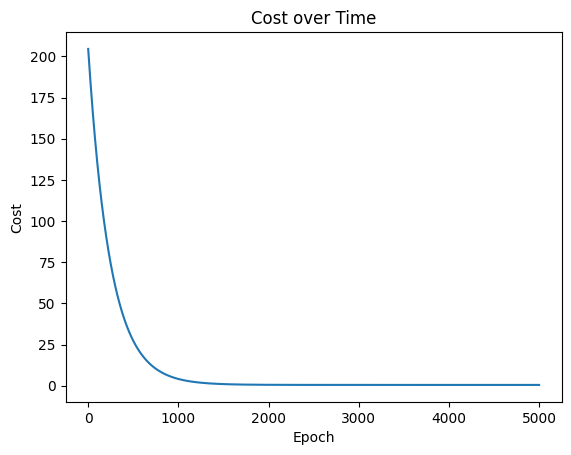

In [73]:
import matplotlib.pyplot as plt
X = np.array([
        [1, 1], 
        [1, 2], 
        [2, 2], 
        [2, 3]
    ])
y = np.array([10, 13, 15, 18])
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
loss = MeanSquaredError()
reg = L2Regularization()
model = GradientDescent(loss,reg,0.001,5000)
model.fit(X_scaled,y)
print(f"Final weights: {model.weights}")
print(f"Final bias: {model.bias}")
plt.plot(model.costs)
plt.title("Cost over Time")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

In [74]:
class Sigmoid():
    def forward(self,z):
        z = np.clip(z,-500,500)
        return 1/(1+np.exp(-z))
    def backward(self,z):
        sig = self.forward(z)
        return sig*(1-sig)

In [75]:
class BinaryCrossEntropy():
    def forward(self,y_true,y_pred):
        m = len(y_true)
        y_pred = np.clip(y_pred,1e-15,1-1e-15)
        return (-1/m)*np.sum(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))
    def backward(self,y_true,y_pred):
        m = len(y_true)
        y_pred = np.clip(y_pred,1e-15,1-1e-15)
        return ((-y_true/y_pred) + ((1-y_true)/(1-y_pred)))/m

In [76]:
class Softmax():
    def forward(self,z):
        z_shifted = z-np.max(z,axis=1,keepdims=True)
        e_z = np.exp(z_shifted)
        return e_z/np.sum(e_z,axis=1,keepdims=True)
    def backward(self,z):
        return 1;

In [77]:
class CategoricalCrossEntropy():
    def forward(self,y_true,y_pred):
        z = y_pred # CategoricalCrossEntropy used when prev activation function is Linear
        z_safe = np.clip(z, -100, 100)
        z_shifted = z-np.max(z,axis=1,keepdims=True) # we manually apply softmax activation function
        exp_z = np.exp(z_shifted)
        probs = exp_z/np.sum(exp_z,axis=1,keepdims=True)
        probs_clipped = np.clip(probs,1e-15,1-1e-15)
        return -np.sum(y_true * np.log(probs_clipped)) / len(y_true)
    def backward(self,y_true,y_pred):
        m = len(y_true)
        return (y_pred-y_true)/m

In [78]:
class LogisticRegression():
    def __init__(self,loss_fn=BinaryCrossEntropy(),reg_fn=None,activation_fn=None,lr=0.001,epochs=1000):
        self.loss = loss_fn
        self.reg = reg_fn
        self.act = activation_fn
        self.lr = lr
        self.epochs = epochs
        self.costs = []
        self.weights = None
        self.bias = 0
    def predict(self,X):
        z = np.dot(X,self.weights)+self.bias
        if self.act:
            return self.act.forward(z)
        else:
            return z
    def fit(self,X,y):
        m,n = X.shape
        self.weights = np.zeros(n)
        for i in range(self.epochs):
            z = np.dot(X,self.weights)+self.bias
            if self.act:
                y_pred = self.act.forward(z)
            else:
                y_pred = z
            cost = self.loss.forward(y,y_pred)
            if self.reg:
                cost += self.reg.forward(self.weights)
            self.costs.append(cost)
            d_pred = self.loss.backward(y,y_pred)
            if self.act:
                d_z = self.act.backward(z)*d_pred
            else:
                d_z = d_pred
            dw = np.dot(X.T,d_z)
            db = np.sum(d_z)
            if self.reg:
                dw += self.reg.backward(self.weights)
            self.weights -= self.lr*dw
            self.bias -= self.lr*db
        return self

Final Cost: 0.0709
Weights: [0.8778821  0.66696741]
Bias: -5.770021094526795
Accuracy: 99.50%


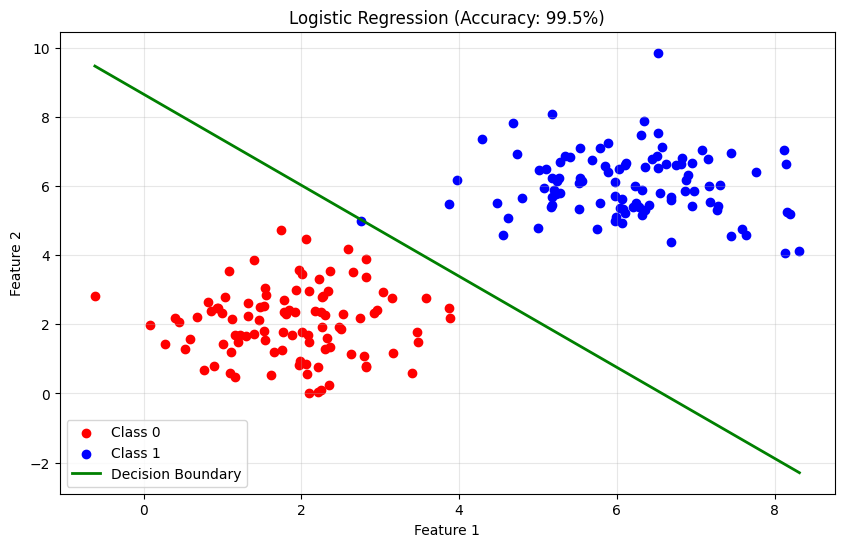

In [79]:
def generate_data(n_samples=200):
    np.random.seed(42) # Fixed seed for reproducibility
    
    # Class 0: Centered at (2, 2)
    x0 = np.random.randn(n_samples // 2, 2) + 2
    y0 = np.zeros(n_samples // 2)
    
    # Class 1: Centered at (6, 6)
    x1 = np.random.randn(n_samples // 2, 2) + 6
    y1 = np.ones(n_samples // 2)
    
    # Combine and Shuffle
    X = np.vstack((x0, x1))
    y = np.concatenate((y0, y1))
    
    # Shuffle order
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    return X[indices], y[indices]
X,y = generate_data()
model = LogisticRegression(
        loss_fn=BinaryCrossEntropy(),
        activation_fn=Sigmoid(),
        lr=0.1,
        epochs=1000)
model.fit(X, y)
print(f"Final Cost: {model.costs[-1]:.4f}")
print(f"Weights: {model.weights}")
print(f"Bias: {model.bias}")
z_final = np.dot(X, model.weights) + model.bias
probs = model.act.forward(z_final)
predictions = (probs >= 0.5).astype(int)
accuracy = np.mean(predictions == y) * 100
print(f"Accuracy: {accuracy:.2f}%")
plt.figure(figsize=(10, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='Class 0')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='Class 1')
    
    # Plot the Decision Boundary Line
    # The line is where z = 0  =>  w1*x1 + w2*x2 + b = 0
    # So: x2 = -(w1*x1 + b) / w2
x1_vals = np.linspace(min(X[:,0]), max(X[:,0]), 100)
w1, w2 = model.weights
b = model.bias
x2_vals = -(w1 * x1_vals + b) / w2
 
plt.plot(x1_vals, x2_vals, color='green', linewidth=2, label='Decision Boundary')
    
plt.title(f"Logistic Regression (Accuracy: {accuracy:.1f}%)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

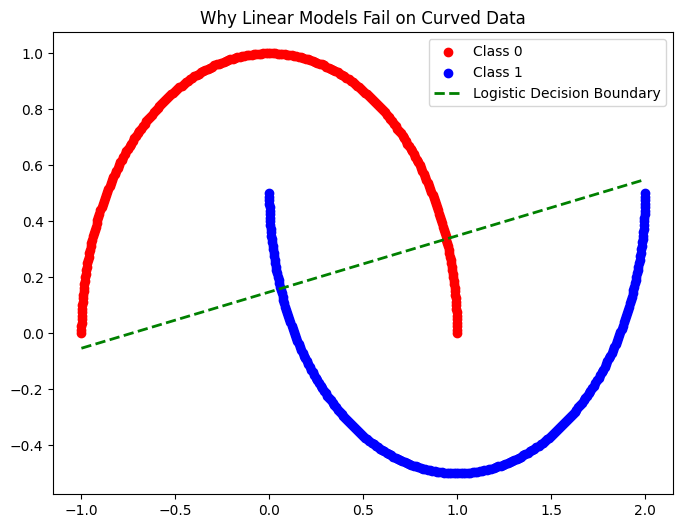

Accuracy: 88.80%


In [80]:
from sklearn.datasets import make_moons

# 1. Generate Non-Linear Data (Moons)
X, y = make_moons(n_samples=500, noise=0, random_state=42)

# 2. Train your Logistic Regression Model
# (Assuming your classes are defined above)
model = LogisticRegression(
    loss_fn=BinaryCrossEntropy(), 
    activation_fn=Sigmoid(), 
    lr=0.1, 
    epochs=3000
)
model.fit(X, y)

# 3. Visualize the Failure
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='Class 0')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='Class 1')

# Plot the straight line decision boundary
x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
slope = -(model.weights[0] / model.weights[1])
intercept = -(model.bias / model.weights[1])
y_vals = slope * x_vals + intercept

plt.plot(x_vals, y_vals, 'g--', linewidth=2, label='Logistic Decision Boundary')
plt.title("Why Linear Models Fail on Curved Data")
plt.legend()
plt.show()
z_final = np.dot(X, model.weights) + model.bias
probs = model.act.forward(z_final)
predictions = (probs >= 0.5).astype(int)
accuracy = np.mean(predictions == y) * 100
print(f"Accuracy: {accuracy:.2f}%")

In [81]:
X, y = make_moons(n_samples=500, noise=0, random_state=42)
X_sq = X**2
X_cb = X**3
X_int = X[:,0:1]*X[:,1:2]
X_poly = np.hstack((X,X_sq,X_int,X_cb))
model = LogisticRegression(
    loss_fn = BinaryCrossEntropy(),
    reg_fn = L2Regularization(0.005),
    activation_fn = Sigmoid(),
    lr = 0.1,
    epochs = 20000
)
model.fit(X_poly,y)
print(model.weights)
z_final = np.dot(X_poly, model.weights) + model.bias
probs = model.act.forward(z_final)
predictions = (probs >= 0.5).astype(int)
accuracy = np.mean(predictions == y) * 100
print(f"Accuracy: {accuracy:.2f}%")

[-0.12403031 -2.50046021 -1.99661878 -0.8666831  -1.05672841  1.54194353
 -1.19573074]
Accuracy: 95.60%


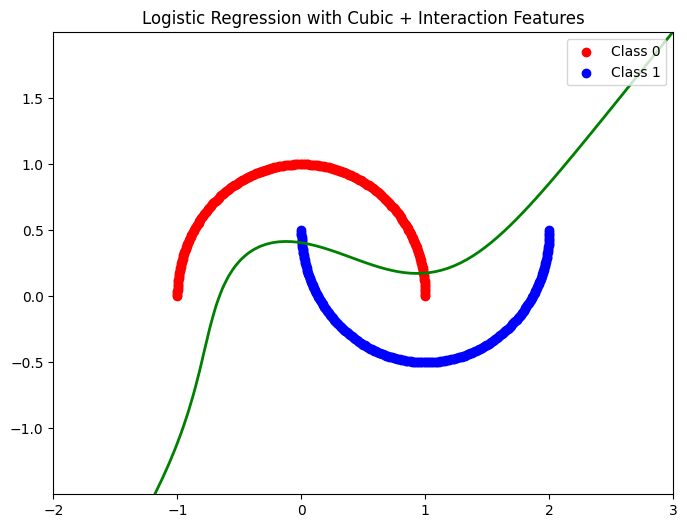

In [82]:
# 3. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='Class 0')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='Class 1')

# Grid Setup
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Flatten grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
gx1 = grid_points[:, 0:1]
gx2 = grid_points[:, 1:2]

# Apply EXACTLY the same feature engineering to grid
g_squared = grid_points ** 2
g_interaction = gx1 * gx2
g_cubic = grid_points ** 3
grid_poly = np.hstack((grid_points, g_squared, g_interaction, g_cubic))

# Predict
z_grid = np.dot(grid_poly, model.weights) + model.bias
probs = model.act.forward(z_grid)
probs = probs.reshape(xx.shape)

# Draw
plt.contour(xx, yy, probs, levels=[0.5], colors='green', linewidths=2)
plt.title("Logistic Regression with Cubic + Interaction Features")
plt.legend()
plt.show()

In [83]:
class Tanh():
    def forward(self,z):
        z = np.clip(z,-500,500)
        return np.tanh(z)
    def backward(self,z):
        a = self.forward(z)
        return 1-a**2

In [84]:
class ReLu():
    def forward(self,z):
        return np.maximum(0,z)
    def backward(self,z):
        return (z>0).astype(float)

In [85]:
class Linear():
    def forward(self,z):
        return z
    def backward(self,z):
        return 1

In [86]:
class Node():
    def __init__(self,act_fn,number_of_weights=0,lr=0.01):
        self.lr = lr
        self.act = act_fn
        std_dev = np.sqrt(2.0/number_of_weights) if number_of_weights>0 else 0.01  #He Init
        self.weights = np.random.randn(number_of_weights)*std_dev
        self.bias = np.ones(1)*0.1
        self.X = None
        self.z = None
    def update(self,lr,dw,db):
        self.weights -= lr*dw
        self.bias -= lr*bias
    def forward(self,X):
        self.X = X
        self.z = np.dot(X, self.weights) + self.bias
        return self.act.forward(self.z)
    def backward(self,d_act):
        d_z = d_act*self.act.backward(self.z)
        d_w = np.dot(self.X.T,d_z)
        d_b = np.sum(d_z)
        self.weights -= self.lr*d_w
        self.bias -= self.lr*d_b
        return np.outer(d_z, self.weights)

In [87]:
class Layer():
    def __init__(self,node_count,act_fn,lr=0.01):
        self.nodes = []
        self.act = act_fn
        self.node_count = node_count
        self.is_built = False
        self.lr = lr
    def build(self,weight_count):
        for i in range(self.node_count):
            self.nodes.append(Node(self.act,weight_count,self.lr))
        self.is_built = True
    def forward(self,X):
        preds = []
        for i in range(self.node_count):
            preds.append(self.nodes[i].forward(X))
        return np.column_stack(preds)
    def backward(self,d_act):
        L = []
        for i in range(self.node_count):
            L.append(self.nodes[i].backward(d_act[:,i]))
        return np.sum(L, axis=0)

In [88]:
class NeuralNetwork():
    def __init__(self,mode="classification",loss_fn=BinaryCrossEntropy()):
        self.loss = loss_fn
        self.layers = []
        self.costs = []
        self.mode = mode
    def add_layer(self,act_fn,lr,node_count=5):
        self.layers.append(Layer(node_count,act_fn,lr))
    def forward(self,X):
        pred = X
        for l in self.layers:
            pred = l.forward(pred)
        return pred
    def backward(self,d_loss):
        error = d_loss
        for l in reversed(self.layers):
            error = l.backward(error)
    def fit(self,X,y,epochs=1000,print_every=200):
        m,n = X.shape
        wt_count = n
        for l in self.layers:
            if not l.is_built:
                l.build(wt_count)
                wt_count = l.node_count
        for i in range(epochs):
            y_pred = self.forward(X)
            cost = self.loss.forward(y,y_pred)
            self.costs.append(cost)
            d_loss = self.loss.backward(y,y_pred)
            self.backward(d_loss)
            if i % print_every == 0:
                print(f"Epoch {i}: Cost {cost:.4f}")
    def predict(self,X,return_probs=False):
        z = self.forward(X)
        if self.mode == "classification":
            z_shifted = z - np.max(z, axis=1, keepdims=True)
            exp_z = np.exp(z_shifted)
            probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)
            if return_probs:
                return probs
            else:
                return np.argmax(probs,axis=1)
        elif self.mode == "regression":
            return z

Generating Data...
Building Network...
Starting Training...
Epoch 0: Cost 0.8995
Epoch 100: Cost 0.5548
Epoch 200: Cost 0.5544
Epoch 300: Cost 0.5542
Epoch 400: Cost 0.5541
Epoch 500: Cost 0.5539
Epoch 600: Cost 0.5538
Epoch 700: Cost 0.5536
Epoch 800: Cost 0.5535
Epoch 900: Cost 0.5534

Final Accuracy: 100.00%

Sample Probabilities (First 3 examples):
[[0.21206822 0.2122215  0.57571028]
 [0.21200496 0.21219812 0.57579692]
 [0.20782882 0.58108364 0.21108754]]

Visualizing Decision Boundaries...


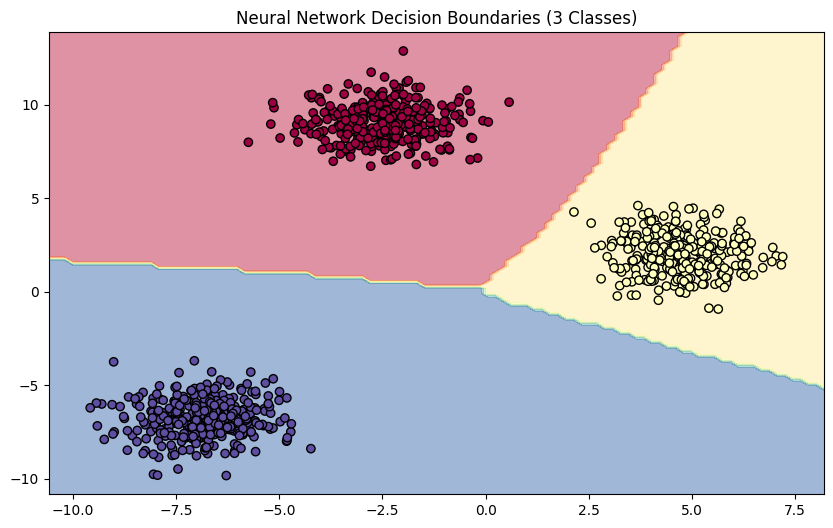

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# --- 1. DATA SETUP ---
print("Generating Data...")
# Create 3 distinct blobs (Classes 0, 1, 2)
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42)

# One-Hot Encode y for training
# 0 -> [1, 0, 0]
# 1 -> [0, 1, 0]
# 2 -> [0, 0, 1]
y_onehot = np.zeros((len(y), 3))
y_onehot[np.arange(len(y)), y] = 1

# --- 2. BUILD NETWORK ---
print("Building Network...")
# Use the robust Cross Entropy loss
nn = NeuralNetwork(mode="classification", loss_fn=CategoricalCrossEntropy())

# Layer 1: Learn features (Tanh is great for hidden layers)
nn.add_layer(node_count=10, act_fn=ReLu(), lr=0.0001)
nn.add_layer(node_count=10, act_fn=Tanh(), lr=0.005)
nn.add_layer(node_count=10, act_fn=Tanh(), lr=0.005)

# Layer 2: Output Layer (Linear - Raw Logits)
# CRITICAL: We use Linear here so the Loss function gets raw scores!
nn.add_layer(node_count=3, act_fn=Linear(), lr=0.1)

# --- 3. TRAIN ---
print("Starting Training...")
nn.fit(X, y_onehot, epochs=1000, print_every=100)

# --- 4. VERIFY PREDICTIONS ---
# Test A: Get Class Labels
predictions = nn.predict(X)
accuracy = np.mean(predictions == y)
print(f"\nFinal Accuracy: {accuracy * 100:.2f}%")

# Test B: Get Probabilities
probs = nn.predict(X, return_probs=True)
print("\nSample Probabilities (First 3 examples):")
print(probs[:3]) 
# Should look like rows summing to 1, e.g., [0.01, 0.98, 0.01]

# --- 5. VISUALIZATION ---
print("\nVisualizing Decision Boundaries...")
plt.figure(figsize=(10, 6))

# Create grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict on grid
grid_X = np.c_[xx.ravel(), yy.ravel()]
grid_preds = nn.predict(grid_X) # Returns 0, 1, or 2
grid_preds = grid_preds.reshape(xx.shape)

# Plot contours
plt.contourf(xx, yy, grid_preds, cmap=plt.cm.Spectral, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, edgecolors='k')

plt.title("Neural Network Decision Boundaries (3 Classes)")
plt.show()